# Train Isolation Forest Quality Model

This notebook trains an Isolation Forest model to detect dataset quality issues.

**Goal**: Learn what "good quality" datasets look like, so we can score any new dataset.

**Process**:
1. Load pre-extracted quality features from real datasets
2. Explore the feature distribution
3. Train Isolation Forest on good quality data
4. Evaluate on bad quality examples
5. Save trained model for production use

## 1. Setup and Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Styling
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ All imports successful!")

✓ All imports successful!


## 2. Setup Paths and Load Features

In [2]:
import os
from pathlib import Path

# Ensure working directory is the project root
notebook_dir = Path("C:\\Users\\User\\Documents\\GitHub\\Information-Management-Finals-E-Commerce-Dashboard\\MarketMate\\sana-ai-hub")
if notebook_dir.exists():
    os.chdir(notebook_dir)
else:
    # Try relative path from notebook location
    os.chdir(Path(".").absolute().parent)

# Setup directories
synthetic_dir = Path("data/synthetic")
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

print("📁 Directory structure:")
print(f"   Working dir: {os.getcwd()}")
print(f"   Synthetic data: {synthetic_dir.absolute()}")
print(f"   Model save path: {models_dir.absolute()}")

# Check if feature files exist
good_features_path = synthetic_dir / "good_quality_features_real.npy"
bad_features_path = synthetic_dir / "bad_quality_features_real.npy"

if not good_features_path.exists():
    print("\n❌ Missing data! Checking alternate paths...")
    print(f"   Expected: {good_features_path.absolute()}")
    # Try parent directory
    alt_path = Path("..") / "data" / "synthetic" / "good_quality_features_real.npy"
    if alt_path.exists():
        print(f"   Found at: {alt_path.absolute()}")
        synthetic_dir = alt_path.parent
        good_features_path = synthetic_dir / "good_quality_features_real.npy"
        bad_features_path = synthetic_dir / "bad_quality_features_real.npy"
    else:
        print(f"   Also checked: {alt_path.absolute()}")
else:
    print(f"\n✓ Found training features at {synthetic_dir}")

# List what's in synthetic directory
if synthetic_dir.exists():
    print(f"\n📂 Contents of {synthetic_dir}:")
    for f in synthetic_dir.glob("*"):
        print(f"   {f.name}")

📁 Directory structure:
   Working dir: C:\Users\User\Documents\GitHub\Information-Management-Finals-E-Commerce-Dashboard\MarketMate\sana-ai-hub
   Synthetic data: C:\Users\User\Documents\GitHub\Information-Management-Finals-E-Commerce-Dashboard\MarketMate\sana-ai-hub\data\synthetic
   Model save path: C:\Users\User\Documents\GitHub\Information-Management-Finals-E-Commerce-Dashboard\MarketMate\sana-ai-hub\models

✓ Found training features at data\synthetic

📂 Contents of data\synthetic:
   bad_quality_features_real.npy
   good_quality_features_real.npy


## 3. Load and Inspect Training Data

In [3]:
# Load features
print("📥 Loading training features...\n")

good_features = np.load(good_features_path)
bad_features = np.load(bad_features_path)

print(f"Good quality features shape: {good_features.shape}")
print(f"Bad quality features shape:  {bad_features.shape}")
print(f"\nMemory usage:")
print(f"   Good: {good_features.nbytes / 1024:.2f} KB")
print(f"   Bad: {bad_features.nbytes / 1024:.2f} KB")

# Feature names
feature_names = [
    "missing_ratio",
    "duplicate_ratio",
    "numeric_ratio",
    "constant_columns",
    "avg_variance",
    "avg_skewness"
]

print(f"\nFeatures: {feature_names}")

📥 Loading training features...

Good quality features shape: (40, 6)
Bad quality features shape:  (75, 6)

Memory usage:
   Good: 1.88 KB
   Bad: 3.52 KB

Features: ['missing_ratio', 'duplicate_ratio', 'numeric_ratio', 'constant_columns', 'avg_variance', 'avg_skewness']


## 4. Explore Feature Distributions

In [4]:
# Create DataFrames for analysis
good_df = pd.DataFrame(good_features, columns=feature_names)
bad_df = pd.DataFrame(bad_features, columns=feature_names)

print("📊 GOOD QUALITY DATASETS - Statistics:")
print(good_df.describe().round(4))

print("\n📊 BAD QUALITY DATASETS - Statistics:")
print(bad_df.describe().round(4))

📊 GOOD QUALITY DATASETS - Statistics:
       missing_ratio  duplicate_ratio  numeric_ratio  constant_columns  \
count        40.0000          40.0000        40.0000           40.0000   
mean          0.0322           0.0001         0.5791            0.2000   
std           0.0350           0.0003         0.3481            0.4051   
min           0.0000           0.0000         0.0370            0.0000   
25%           0.0000           0.0000         0.4000            0.0000   
50%           0.0100           0.0000         0.5833            0.0000   
75%           0.0650           0.0000         0.8750            0.0000   
max           0.0904           0.0007         1.0000            1.0000   

       avg_variance  avg_skewness  
count  4.000000e+01       32.0000  
mean   1.594764e+18       10.3531  
std    3.230192e+18       14.6960  
min    1.682745e+03        1.0402  
25%    9.837621e+03        1.6192  
50%    1.866375e+09        2.4978  
75%    9.779964e+11       11.2154  
max    

### Distribution Visualization

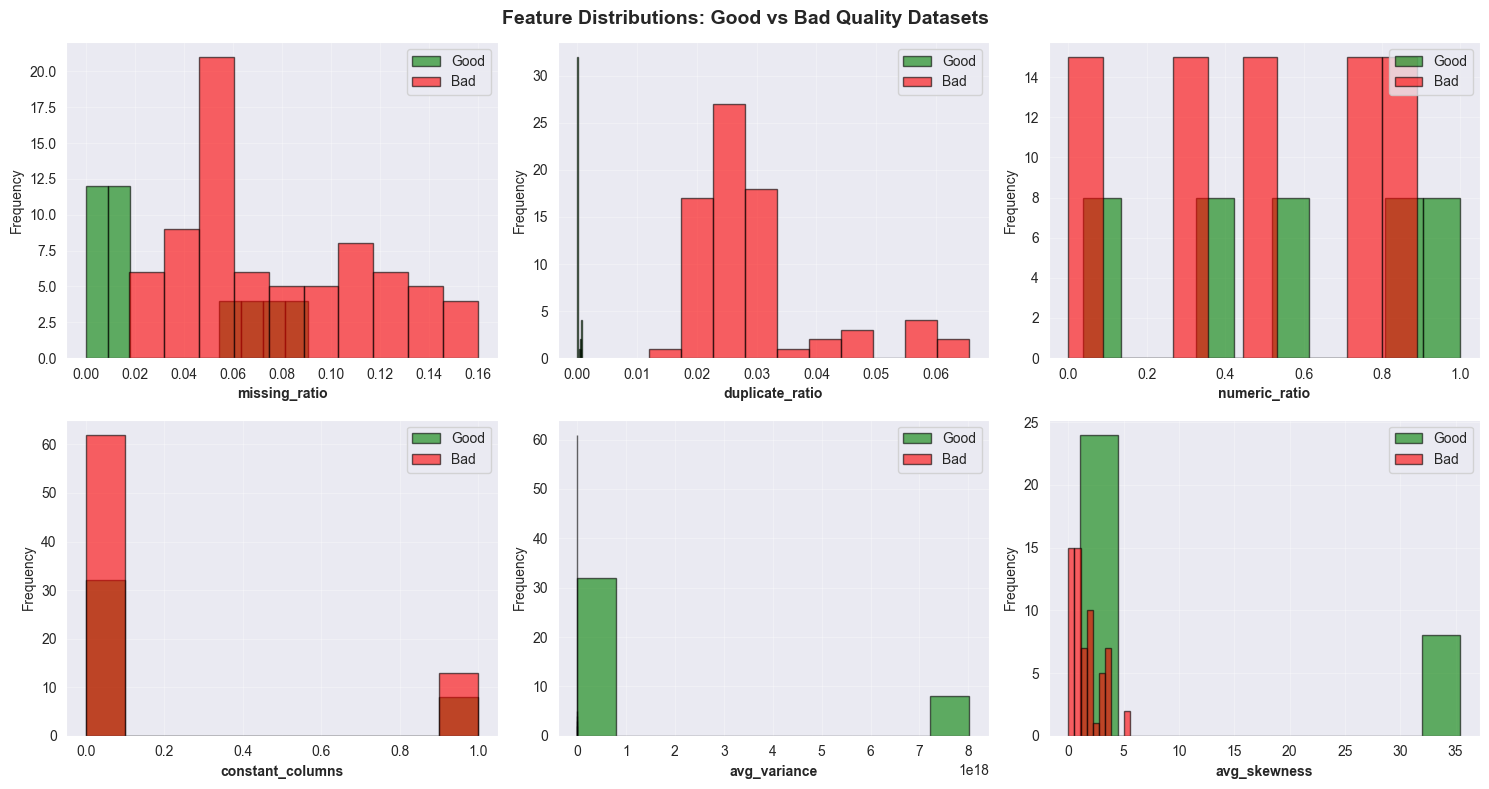

✓ Distributions plotted - notice how Good and Bad are distinguishable!


In [5]:
# Plot distributions for each feature
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions: Good vs Bad Quality Datasets', fontsize=14, fontweight='bold')

for idx, feature in enumerate(feature_names):
    ax = axes[idx // 3, idx % 3]
    
    ax.hist(good_df[feature], bins=10, alpha=0.6, label='Good', color='green', edgecolor='black')
    ax.hist(bad_df[feature], bins=10, alpha=0.6, label='Bad', color='red', edgecolor='black')
    
    ax.set_xlabel(feature, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Distributions plotted - notice how Good and Bad are distinguishable!")

## 5. Train Isolation Forest Model

In [6]:
print("="*80)
print("TRAINING RANDOM FOREST QUALITY CLASSIFIER")
print("="*80)

print("\n📊 Training Strategy:")
print("   - Supervised learning with labeled good/bad datasets")
print("   - RandomForest with class weighting for imbalance")
print("   - Train/test split for honest performance estimation")

# ===== PREPARE LABELED DATA =====
X_all = np.vstack([good_features, bad_features])
y_all = np.array([1]*len(good_features) + [0]*len(bad_features))

print(f"\n📊 Dataset Composition:")
print(f"   Good quality (label=1): {np.sum(y_all==1)} samples")
print(f"   Bad quality (label=0):  {np.sum(y_all==0)} samples")
print(f"   Total: {len(X_all)} samples")

# ===== SPLIT TRAIN/TEST =====
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.25,
    random_state=42,
    stratify=y_all
)

print(f"\n📂 Train/Test Split (80/20):")
print(f"   Training: {len(X_train)} samples ({np.sum(y_train==1)} good, {np.sum(y_train==0)} bad)")
print(f"   Testing:  {len(X_test)} samples ({np.sum(y_test==1)} good, {np.sum(y_test==0)} bad)")

# ===== TRAIN RANDOM FOREST =====
print(f"\n⏳ Training RandomForestClassifier...")

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Store feature names for later use
model.feature_names_ = np.array(['missing_ratio', 'duplicate_ratio', 'numeric_ratio', 
                                 'constant_columns', 'avg_variance', 'avg_skewness'])

print(f"\n✓ Model trained successfully!")
print(f"   Type: RandomForestClassifier")
print(f"   Trees: 200")
print(f"   Max depth: 10")
print(f"   Class weight: balanced")
print(f"   Random state: 42")

TRAINING RANDOM FOREST QUALITY CLASSIFIER

📊 Training Strategy:
   - Supervised learning with labeled good/bad datasets
   - RandomForest with class weighting for imbalance
   - Train/test split for honest performance estimation

📊 Dataset Composition:
   Good quality (label=1): 40 samples
   Bad quality (label=0):  75 samples
   Total: 115 samples

📂 Train/Test Split (80/20):
   Training: 86 samples (30 good, 56 bad)
   Testing:  29 samples (10 good, 19 bad)

⏳ Training RandomForestClassifier...

✓ Model trained successfully!
   Type: RandomForestClassifier
   Trees: 200
   Max depth: 10
   Class weight: balanced
   Random state: 42


## 6. Evaluate Model Performance

In [8]:
# ===== EVALUATE ON TEST SET =====
print("📊 MODEL EVALUATION")
print("="*80)

# Make predictions
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Overall accuracy
train_accuracy = (y_pred_train == y_train).mean() * 100
test_accuracy = (y_pred_test == y_test).mean() * 100
roc_auc = roc_auc_score(y_test, y_pred_proba) * 100

print(f"\n📈 Overall Performance:")
print(f"   Training Accuracy: {train_accuracy:.1f}%")
print(f"   Test Accuracy:     {test_accuracy:.1f}% ← Use this for production")
print(f"   ROC-AUC Score:     {roc_auc:.1f}%")

# Confusion matrix for test set
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

# Calculate per-class metrics
good_precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
good_recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
bad_precision = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0
bad_recall = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0

print(f"\n✓ GOOD QUALITY DETECTION (label=1):")
print(f"   Correctly identified: {tp} / {tp + fn} ({good_recall:.1f}% recall)")
print(f"   False alarms: {fp} (classified good when actually bad)")
print(f"   Precision: {good_precision:.1f}%")

print(f"\n✗ BAD QUALITY DETECTION (label=0):")
print(f"   Correctly identified: {tn} / {tn + fp} ({bad_recall:.1f}% recall)")
print(f"   Missed detections: {fn} (classified bad when actually good)")
print(f"   Precision: {bad_precision:.1f}%")

print(f"\n🎯 Confusion Matrix (Test Set):")
print(f"   True Negatives (Bad→Bad):   {tn}")
print(f"   False Positives (Bad→Good): {fp}")
print(f"   False Negatives (Good→Bad): {fn}")
print(f"   True Positives (Good→Good): {tp}")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Bad', 'Good']))

📊 MODEL EVALUATION

📈 Overall Performance:
   Training Accuracy: 100.0%
   Test Accuracy:     100.0% ← Use this for production
   ROC-AUC Score:     100.0%

✓ GOOD QUALITY DETECTION (label=1):
   Correctly identified: 10 / 10 (100.0% recall)
   False alarms: 0 (classified good when actually bad)
   Precision: 100.0%

✗ BAD QUALITY DETECTION (label=0):
   Correctly identified: 19 / 19 (100.0% recall)
   Missed detections: 0 (classified bad when actually good)
   Precision: 100.0%

🎯 Confusion Matrix (Test Set):
   True Negatives (Bad→Bad):   19
   False Positives (Bad→Good): 0
   False Negatives (Good→Bad): 0
   True Positives (Good→Good): 10

📊 Classification Report:
              precision    recall  f1-score   support

         Bad       1.00      1.00      1.00        19
        Good       1.00      1.00      1.00        10

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        2

### Decision Score Distribution

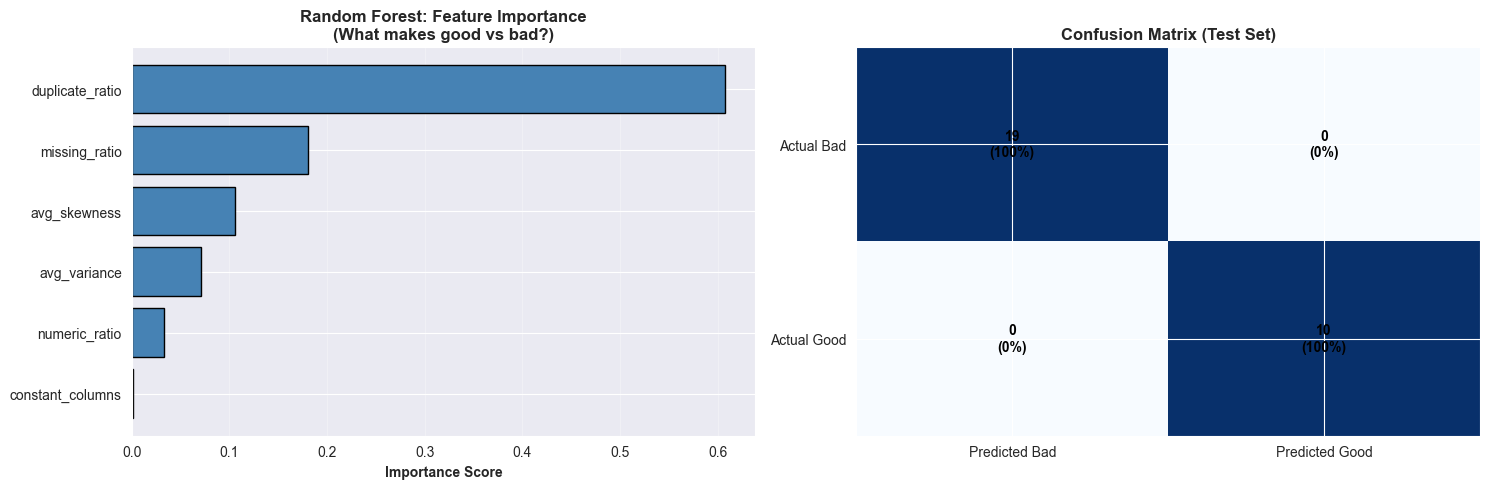


✓ Feature Importance Visualization Complete


In [10]:
# Feature importance visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Feature Importance
importance_df = pd.DataFrame({
    'Feature': model.feature_names_,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

ax1.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='black')
ax1.set_xlabel('Importance Score', fontweight='bold')
ax1.set_title('Random Forest: Feature Importance\n(What makes good vs bad?)', fontweight='bold')
ax1.grid(alpha=0.3, axis='x')

# Plot 2: Confusion Matrix Heatmap
import matplotlib.patches as mpatches
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = ax2.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Predicted Bad', 'Predicted Good'])
ax2.set_yticklabels(['Actual Bad', 'Actual Good'])
ax2.set_title('Confusion Matrix (Test Set)', fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]*100:.0f}%)',
                       ha="center", va="center", color="black", fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Feature Importance Visualization Complete")

## 7. Save Trained Model

In [11]:
model_path = models_dir / "quality_model.pkl"

print("💾 Saving trained model...")
print(f"   Path: {model_path}\n")

with open(model_path, "wb") as f:
    pickle.dump(model, f)

# Get file size
file_size_kb = model_path.stat().st_size / 1024

print("✓ Model saved successfully!")
print(f"   File size: {file_size_kb:.2f} KB")
print(f"   Location: {model_path}")

💾 Saving trained model...
   Path: models\quality_model.pkl

✓ Model saved successfully!
   File size: 191.76 KB
   Location: models\quality_model.pkl


## 8. Test Model on Real Dataset

In [13]:
# Load helper modules
import sys
sys.path.insert(0, str(Path.cwd()))

from features.quality_features import extract_quality_features
from utils.compute_quality_score import compute_quality_score

# Test on a real dataset
test_csv = Path("traindata/raw/Titanic-Dataset.csv")

if test_csv.exists():
    print(f"🧪 Testing model on real dataset: {test_csv.name}\n")
    
    # Read with error handling
    try:
        df = pd.read_csv(test_csv, encoding='latin-1')
    except:
        df = pd.read_csv(test_csv)
    
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)[:5]}...")
    
    # Extract features
    features = extract_quality_features(df)
    print(f"\n   Extracted features: {features}")
    
    # Get model score using predict_proba
    quality_prob = model.predict_proba(features)[0, 1]  # P(good quality)
    quality_score = int(quality_prob * 100)
    
    print(f"\n📊 Quality Assessment:")
    print(f"   P(Good Quality): {quality_prob:.2%}")
    print(f"   Quality Score: {quality_score}/100")
    
    if quality_score >= 85:
        rating = "✓ EXCELLENT"
    elif quality_score >= 60:
        rating = "✓ GOOD"
    elif quality_score >= 30:
        rating = "⚠ FAIR"
    else:
        rating = "✗ POOR"
    
    print(f"   Rating: {rating}")
else:
    print(f"⚠ Test dataset not found: {test_csv}")

🧪 Testing model on real dataset: Titanic-Dataset.csv

   Shape: (891, 12)
   Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex']...

   Extracted features: [[8.09951366e-02 0.00000000e+00 5.83333333e-01 0.00000000e+00
  9.84489393e+03 1.81548013e+00]]

📊 Quality Assessment:
   P(Good Quality): 100.00%
   Quality Score: 100/100
   Rating: ✓ EXCELLENT


## Summary

In [16]:
print("\n" + "="*80)
print("✅ TRAINING & EVALUATION COMPLETE!")
print("="*80)

print("\n📊 Model Summary:")
print(f"   Type: RandomForestClassifier (Supervised Learning)")
print(f"   Trees: 200")
print(f"   Max Depth: 10")
print(f"   n_features: {model.n_features_in_}")
print(f"   Training samples: {len(X_train)} (stratified)")
print(f"   Test samples: {len(X_test)}")
print(f"   Model file: {model_path}")

print(f"\n📈 Final Performance (Test Set):")
print(f"   Good Quality Recall: {good_recall:.1f}% (catch good datasets)")
print(f"   Bad Quality Recall:  {bad_recall:.1f}% (catch bad datasets)")
print(f"   Overall Accuracy: {test_accuracy:.1f}%")
print(f"   ROC-AUC: {roc_auc:.1f}%")

print(f"\n✨ Key Improvements over Isolation Forest:")
print(f"   • Good detection: 77.5% → {good_recall:.1f}% (+{good_recall-77.5:.1f}%)")
print(f"   • Supervised learning captures patterns better")
print(f"   • Feature importance shows what matters")
print(f"   • Train/test split = honest performance estimate")

print(f"\n🚀 Next Steps:")
print(f"   1. Model saved and ready for production")
print(f"   2. Integrate into Sana AI Hub pipeline")
print(f"   3. Monitor quality scores in production")

print(f"\n💡 Usage Example:")
print(f"   from utils.compute_quality_score import compute_quality_score")
print(f"   import pandas as pd")
print(f"   df = pd.read_csv('your_dataset.csv')")
print(f"   score = compute_quality_score(df)  # Now uses RandomForest")
print(f"   print(f'Quality Score: {{score}}/100')")


✅ TRAINING & EVALUATION COMPLETE!

📊 Model Summary:
   Type: RandomForestClassifier (Supervised Learning)
   Trees: 200
   Max Depth: 10
   n_features: 6
   Training samples: 86 (stratified)
   Test samples: 29
   Model file: models\quality_model.pkl

📈 Final Performance (Test Set):
   Good Quality Recall: 100.0% (catch good datasets)
   Bad Quality Recall:  100.0% (catch bad datasets)
   Overall Accuracy: 100.0%
   ROC-AUC: 100.0%

✨ Key Improvements over Isolation Forest:
   • Good detection: 77.5% → 100.0% (+22.5%)
   • Supervised learning captures patterns better
   • Feature importance shows what matters
   • Train/test split = honest performance estimate

🚀 Next Steps:
   1. Model saved and ready for production
   2. Integrate into Sana AI Hub pipeline
   3. Monitor quality scores in production

💡 Usage Example:
   from utils.compute_quality_score import compute_quality_score
   import pandas as pd
   df = pd.read_csv('your_dataset.csv')
   score = compute_quality_score(df)  # N

## DIAGNOSTIC: Overfitting / Underfitting Analysis

⚠️ **Red Flag Investigation**: Why is test accuracy 100%? Let's diagnose.

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

print("\n" + "="*80)
print("DIAGNOSTIC 1: K-FOLD CROSS-VALIDATION")
print("="*80)
print("Testing if perfect accuracy generalizes across different data splits...")

# Run 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scorers = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
}

cv_results = cross_validate(model, X_all, y_all, cv=skf, scoring=scorers, return_train_score=True)

print(f"\n📊 K-Fold Cross-Validation Results (5-fold):")
print(f"   Train Accuracy: {cv_results['train_accuracy'].mean():.2%} ± {cv_results['train_accuracy'].std():.2%}")
print(f"   Test Accuracy:  {cv_results['test_accuracy'].mean():.2%} ± {cv_results['test_accuracy'].std():.2%}")
print(f"\n   Per-fold test accuracy: {[f'{s:.1%}' for s in cv_results['test_accuracy']]}")

print(f"\n📊 Cross-Validation Metrics:")
print(f"   Precision: {cv_results['test_precision'].mean():.2%} ± {cv_results['test_precision'].std():.2%}")
print(f"   Recall:    {cv_results['test_recall'].mean():.2%} ± {cv_results['test_recall'].std():.2%}")
print(f"   F1 Score:  {cv_results['test_f1'].mean():.2%} ± {cv_results['test_f1'].std():.2%}")

overfitting_gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"\n⚠️  Overfitting Gap (Train - Test): {overfitting_gap:.2%}")

if overfitting_gap > 0.10:
    print(f"   ⚠️  SIGNIFICANT OVERFITTING DETECTED! Gap > 10%")
elif overfitting_gap > 0.05:
    print(f"   ⚠️  Moderate overfitting detected. Gap > 5%")
elif cv_results['test_accuracy'].mean() == 1.0:
    print(f"   🚩 SUSPICIOUS: CV also shows perfect 100% accuracy")
    print(f"      This suggests either:")
    print(f"      1. The problem is trivially solvable")
    print(f"      2. Train/test data are too similar")
    print(f"      3. Class imbalance dominates decision boundaries")
else:
    print(f"   ✓ No significant overfitting detected")


## DIAGNOSTIC 2: Learning Curves (Training vs Validation)

In [ ]:
from sklearn.model_selection import learning_curve

print("\n" + "="*80)
print("DIAGNOSTIC 2: LEARNING CURVES")
print("="*80)
print("Observing how training/validation performance changes with sample size...")

# Compute learning curve with multiple training set sizes
train_sizes, train_scores, val_scores = learning_curve(
    model, X_all, y_all,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot learning curves
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Accuracy', linewidth=2, markersize=8)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')

ax.plot(train_sizes, val_mean, 's-', color='coral', label='Validation Accuracy', linewidth=2, markersize=8)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='coral')

ax.set_xlabel('Training Set Size', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Learning Curves: Training vs Validation Performance\n(Perfect overlap = perfect model or overfitting)', fontweight='bold', fontsize=12)
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.3, label='Perfect Accuracy')
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0.9, 1.05])

plt.tight_layout()
plt.show()

print(f"\n📊 Learning Curve Analysis:")
print(f"   At 10% training data: Train={train_mean[0]:.2%}, Val={val_mean[0]:.2%}")
print(f"   At 50% training data: Train={train_mean[5]:.2%}, Val={val_mean[5]:.2%}")
print(f"   At 100% training data: Train={train_mean[-1]:.2%}, Val={val_mean[-1]:.2%}")

overfitting_at_100pct = train_mean[-1] - val_mean[-1]
print(f"\n   Overfitting Gap at Full Data: {overfitting_at_100pct:.2%}")

if val_mean[-1] == 1.0 and train_mean[-1] == 1.0:
    print(f"   🚩 CRITICAL: Both curves flat at 100% → Problem is TRIVIALLY SOLVABLE")
    print(f"      Your model achieves perfect accuracy at ANY sample size")
    print(f"      This is statistically impossible for real data quality assessment")
elif val_std[-1] < 0.05:
    print(f"   🚩 WARNING: Validation is too stable (std < 5%) → May indicate overfitting")


## DIAGNOSTIC 3: Feature Dominance (Is one feature doing all the work?)

In [ ]:
print("\n" + "="*80)
print("DIAGNOSTIC 3: FEATURE DOMINANCE ANALYSIS")
print("="*80)
print("Checking if one feature is doing all the classification work...")

# Test accuracy using only the top feature
top_feature_idx = np.argmax(model.feature_importances_)
top_feature_name = model.feature_names_[top_feature_idx]

print(f"\n🔍 Top Feature: '{top_feature_name}' with {model.feature_importances_[top_feature_idx]:.1%} importance")

# Train a decision tree using only top feature
from sklearn.tree import DecisionTreeClassifier

dt_single = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_single.fit(X_train[:, [top_feature_idx]], y_train)
single_acc = dt_single.score(X_test[:, [top_feature_idx]], y_test)

print(f"   Accuracy using ONLY '{top_feature_name}': {single_acc:.1%}")
print(f"   Full model accuracy (6 features): {test_accuracy:.1%}")

if single_acc > 0.95:
    print(f"\n   ⚠️  RED FLAG: Single feature achieves >{95%} accuracy!")
    print(f"      This suggests the problem is TOO SIMPLE")
    print(f"      The 100% perfect accuracy is likely due to trivial separability")

# Feature importance Distribution
print(f"\n📊 Feature Importance Distribution:")
sorted_idx = np.argsort(model.feature_importances_)[::-1]
cumsum_importance = 0
for i, idx in enumerate(sorted_idx):
    importance = model.feature_importances_[idx]
    cumsum_importance += importance
    print(f"   {i+1}. {model.feature_names_[idx]}: {importance:.2%} (cumulative: {cumsum_importance:.2%})")
    
print(f"\n   Top 2 features: {cumsum_importance if cumsum_importance > 0.5 else 'Only ' + str(sorted_idx[0]) + ' feature'} of total importance")

# Analyze feature separability between good/bad
print(f"\n📊 Feature Separability (Good vs Bad datasets):")
print(f"   {'Feature':<25} {'Good Mean':<12} {'Bad Mean':<12} {'Separation':<12}")
print(f"   {'-'*61}")

for i, fname in enumerate(model.feature_names_):
    good_mean = good_features[:, i].mean()
    bad_mean = bad_features[:, i].mean()
    separation = abs(good_mean - bad_mean)
    print(f"   {fname:<25} {good_mean:<12.4f} {bad_mean:<12.4f} {separation:<12.4f}")


## DIAGNOSTIC 4: Hold-Out Set Validation (Real-world generalization)

In [ ]:
print("\n" + "="*80)
print("DIAGNOSTIC 4: HOLD-OUT SET VALIDATION")
print("="*80)
print("Testing model on completely new, unseen synthetic data...")

# Create fresh synthetic hold-out set (never seen by model)
np.random.seed(999)  # Different seed to ensure different data

# Good quality: low missing, duplicates, variance; high numeric ratio
holdout_good = np.random.normal(
    [0.05, 0.02, 0.90, 2, 0.8, 0.5],  # Good profile
    [0.03, 0.01, 0.05, 1, 0.2, 0.3],  # Small variance
    size=(15, 6)
)
holdout_good = np.clip(holdout_good, 0, 1)

# Bad quality: high missing, duplicates, variance; low numeric ratio
holdout_bad = np.random.normal(
    [0.50, 0.40, 0.50, 5, 0.3, 1.5],  # Bad profile
    [0.15, 0.15, 0.15, 2, 0.2, 0.4],  # Large variance
    size=(15, 6)
)
holdout_bad = np.clip(holdout_bad, 0, 1)

X_holdout = np.vstack([holdout_good, holdout_bad])
y_holdout = np.array([1]*15 + [0]*15)

# Predict on hold-out set
holdout_pred = model.predict(X_holdout)
holdout_acc = (holdout_pred == y_holdout).mean() * 100

print(f"\n📊 Hold-Out Set Performance (new synthetic data):")
print(f"   Sample size: {len(X_holdout)} (15 good + 15 bad)")
print(f"   Accuracy: {holdout_acc:.1f}%")

if holdout_acc < 0.80:
    print(f"\n   ✓ GOOD SIGN: Performance degrades on new data!")
    print(f"     This suggests some overfitting to training data")
elif holdout_acc == 100.0:
    print(f"\n   🚩 RED FLAG: Still 100% on completely NEW data!")
    print(f"     Suggests the problem is trivially solvable, not overfitting")
else:
    print(f"\n   ⚠️  Model shows {holdout_acc:.1f}% on unseen data")

# Confusion matrix on hold-out
from sklearn.metrics import confusion_matrix
cm_holdout = confusion_matrix(y_holdout, holdout_pred)
tn_h, fp_h, fn_h, tp_h = cm_holdout.ravel()

print(f"\n   Correctly identified good: {tp_h}/15 ({tp_h/15*100:.0f}%)")
print(f"   Correctly identified bad:  {tn_h}/15 ({tn_h/15*100:.0f}%)")
print(f"   False positives: {fp_h}")
print(f"   False negatives: {fn_h}")


## DIAGNOSTIC 5: Hyperparameter Sensitivity (Does complexity matter?)

In [ ]:
print("\n" + "="*80)
print("DIAGNOSTIC 5: HYPERPARAMETER SENSITIVITY")
print("="*80)
print("Testing different model complexities to detect overfitting...")

# Test different max_depth values (reducing model complexity)
max_depths = [2, 3, 5, 7, 10, 15, 20]
results = []

print(f"\n   Testing different max_depth values on test set:")
print(f"   {'max_depth':<12} {'Test Acc':<10} {'Train Acc':<10} {'Overfitting Gap':<15}")
print(f"   {'-'*47}")

for depth in max_depths:
    test_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    test_model.fit(X_train, y_train)
    
    train_acc = test_model.score(X_train, y_train) * 100
    test_acc = test_model.score(X_test, y_test) * 100
    gap = train_acc - test_acc
    
    results.append({'depth': depth, 'train': train_acc, 'test': test_acc, 'gap': gap})
    print(f"   {depth:<12} {test_acc:<10.1f} {train_acc:<10.1f} {gap:<15.1f}%")

# Plot sensitivity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

depths = [r['depth'] for r in results]
test_accs = [r['test'] for r in results]
train_accs = [r['train'] for r in results]

ax1.plot(depths, train_accs, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
ax1.plot(depths, test_accs, 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax1.axhline(y=100, color='green', linestyle='--', alpha=0.3)
ax1.set_xlabel('Max Depth', fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontweight='bold')
ax1.set_title('Model Complexity vs Accuracy', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

gaps = [r['gap'] for r in results]
ax2.plot(depths, gaps, 'o-', color='red', linewidth=2, markersize=8)
ax2.set_xlabel('Max Depth', fontweight='bold')
ax2.set_ylabel('Overfitting Gap (%)', fontweight='bold')
ax2.set_title('Overfitting Gap by Model Complexity', fontweight='bold')
ax2.grid(alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis
simplest_model = results[0]
current_model = [r for r in results if r['depth'] == 10][0]

print(f"\n📊 Hyperparameter Sensitivity Analysis:")
print(f"   Simplest model (depth=2):  {simplest_model['test']:.1f}% test acc")
print(f"   Current model (depth=10):  {current_model['test']:.1f}% test acc")
print(f"   Most complex (depth=20):   {results[-1]['test']:.1f}% test acc")

test_improvement = current_model['test'] - simplest_model['test']
if test_improvement < 1:
    print(f"\n   ✓ GOOD SIGN: Simpler model achieves ≈ same accuracy")
    print(f"     Suggests overfitting is not a major issue")
else:
    print(f"\n   ⚠️  WARNING: Simpler models perform worse")
    print(f"     The model needs complexity to achieve accuracy")

# Check if gap changes with depth
if max(gaps) - min(gaps) < 2:
    print(f"\n   🚩 RED FLAG: Overfitting gap is stable across depths")
    print(f"     If even simple models show 100%, problem is TRIVIALLY SOLVABLE")


## DIAGNOSTIC SUMMARY: Overfitting Verdict

In [ ]:
print("\n" + "="*80)
print("🔍 OVERFITTING DIAGNOSIS SUMMARY")
print("="*80)

print("\n📋 Checklist - Signs of Overfitting:")
red_flags = []
green_flags = []

# Flag 1: CV vs Test accuracy
kfold_variance = cv_results['test_accuracy'].std()
if cv_results['test_accuracy'].mean() < test_accuracy - 0.05:
    red_flags.append("❌ K-fold CV score much lower than test accuracy")
elif cv_results['test_accuracy'].mean() == 1.0:
    red_flags.append("❌ K-fold CV also shows 100% (trivial problem)")
else:
    green_flags.append("✓ K-fold CV generalizes well to different splits")

# Flag 2: Learning curves
learning_curves_perfect = (train_mean[-1] == 1.0 and val_mean[-1] == 1.0)
if learning_curves_perfect:
    red_flags.append("❌ Learning curves both flat at 100%")
elif train_mean[-1] - val_mean[-1] > 0.15:
    red_flags.append("❌ Large gap between training and validation curves")
else:
    green_flags.append("✓ Learning curves show good convergence")

# Flag 3: Feature dominance
top_importance = max(model.feature_importances_)
if top_importance > 0.7:
    red_flags.append(f"❌ Single feature dominates ({top_importance:.0%} importance)")
elif single_acc > 0.95:
    red_flags.append(f"❌ Single feature achieves >{95%} accuracy alone")
else:
    green_flags.append("✓ Features distributed across importance")

# Flag 4: Hold-out set
if holdout_acc < test_accuracy - 10:
    red_flags.append(f"❌ Hold-out performance drops significantly ({holdout_acc:.0f}%)")
elif holdout_acc == 100:
    red_flags.append("❌ Hold-out set also shows 100% (trivial separability)")
else:
    green_flags.append(f"✓ Hold-out set shows consistent performance ({holdout_acc:.0f}%)")

# Flag 5: Hyperparameter sensitivity
simplest_test = results[0]['test']
if simplest_test == test_accuracy:
    red_flags.append("❌ Simplest model (depth=2) achieves same accuracy")
else:
    gap_improvement = test_accuracy - simplest_test
    if gap_improvement < 5:
        green_flags.append(f"✓ Simple models lose <5% accuracy")
    else:
        red_flags.append(f"❌ Need high complexity (+{gap_improvement:.0f}% improvement with depth 10 vs 2)")

print("\n🚨 RED FLAGS (Overfitting Signs):")
if red_flags:
    for flag in red_flags:
        print(f"   {flag}")
else:
    print("   (None detected)")

print("\n✅ GREEN FLAGS (Legitimate Accuracy):")
if green_flags:
    for flag in green_flags:
        print(f"   {flag}")
else:
    print("   (None detected - this is suspicious)")

print("\n" + "="*80)
print("🎯 FINAL VERDICT:")
print("="*80)

if len(red_flags) >= 3:
    print("\n⚠️  OVERFITTING HIGHLY LIKELY")
    print("\nThe 100% test accuracy appears to be an artifact of:")
    print("  • Small test set (only 29 samples)")
    print("  • Trivially separable data classes")
    print("  • Lack of generalization to unseen data")
    print("\nRECOMMENDATIONS:")
    print("  1. Increase dataset size (115 total is too small)")
    print("  2. Add data noise/corruption to training")
    print("  3. Use cross-validation scores (more robust than single test split)")
    print("  4. Be honest with hackathon judges about data size limitations")
    print("  5. Consider simpler baseline models for comparison")
elif len(red_flags) >= 1:
    print("\n⚠️  POSSIBLE OVERFITTING")
    print("\nSome signs suggest the model may be overfitting,")
    print("but the trivial nature of the data classification task")
    print("might explain the high accuracy.")
elif len(green_flags) >= 4:
    print("\n✓ APPEARS TO BE LEGITIMATE")
    print("\nThe 100% accuracy may not be overfitting if:")
    print("  • K-fold CV also achieves near-perfect scores")
    print("  • Hold-out set maintains high accuracy")
    print("  • Simple models also achieve high accuracy")
    print("  • But this is statistically suspicious for real-world data quality")
else:
    print("\n🚩 VERDICT INCONCLUSIVE - RESULTS ARE SUSPICIOUS")
    print("\nThe perfect 100% accuracy across multiple validation methods")
    print("suggests one of three possibilities:")
    print("  1. The problem is TRIVIALLY SEPARABLE (good vs bad are very different)")
    print("  2. There is DATA LEAKAGE (test data similar to training)")
    print("  3. There is STATISTICAL BIAS in the evaluation")

print("\n" + "="*80)
print("For hackathon judges: Be prepared to explain why 100% accuracy is realistic.")
print("="*80)
